In [9]:
uv pip install git+https://github.com/Abiyzelalem27/CQD_SS26.git

Using Python 3.12.12 environment at: /opt/conda/envs/anaconda-2025.12-py312
Resolved 102 packages in 385ms                                       
error: failed to remove file `/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/../../../bin/jupyter-kernel`: Permission denied (os error 13)
Note: you may need to restart the kernel to use updated packages.


# Exercise 4: Coupled oscillators

## The problem

Consider two coupled harmonic oscillators described by the Hamiltonian
$$
H=H_1 + H_2 + V =\frac{1}{2m}(p_1^2 + p_2^2) + \frac{1}{2}k(x_1^2 + x_2^2) + \frac{1}{2}\lambda(x_1 - x_2)^2
$$
We want to calculate the eigenvalues and eigenfunctions of this Hamiltonian and compare its dynamics to the dynamics of the corresponding classical problem. This problem is exactly solvable by transforming into center of mass and relative coordinates. However, as an exercise on how basis set expansion methods work, we want to treat the coupling term lambda as a perturbation and solve the problem by expanding into eigenfunctions of the uncoupled 2D harmonic oscillator and diagonalizaing the resulting Hamiltonian.

In [2]:
import sys
import os

#Python finds the package
sys.path.append('..')

# load standard libraries
import numpy as np   # standard numerics library
import numpy.linalg as LA

import matplotlib.pyplot as plt   # for making plots

import time as time

import scipy.sparse.linalg as sLA
from scipy.sparse import coo_matrix

from ipywidgets import interactive
from scipy import sparse
from scipy.linalg import eigh
from scipy.sparse.linalg import eigsh
from scipy.special import factorial

import Comp_Quant_Dynam as cqd

### Exercise 1

Transforming into center of mass and relative coordinates (normal modes)


\begin{aligned}
x_{\mathrm{CM}} &= \frac{x_1 + x_2}{2} \\
x_{\mathrm{rel}} &= x_1 - x_2
\end{aligned}
the Hamiltonian becomes

$$
H=\frac{p_{CM}^2}{2M}+\frac{p_{rel}^2}{2\mu} + \frac{1}{2}k_{CM}x_{CM}^2 + \frac{1}{2}k_{rel}x_{rel}^2 
$$
with $M=2m$, $\mu=m/2$, $k_{CM}=2k$, $k_{rel}=k/2+\lambda$. Thus the problem separates into two independent oscillators with frequencies 
\begin{aligned}
\omega_{CM} = \sqrt{\frac{k_{CM}}{M}} =\sqrt{\frac{k}{m}} =\omega \\
\omega_{rel} = \sqrt{\frac{k_{rel}}{\mu}} = \omega\sqrt{1+2\lambda/k}
\end{aligned}

With this, one can write down the solution of the problem in the new coordinates as
\begin{aligned}
x_{CM}(t) = A_{CM} \cos(\omega t)+B_{CM} \sin(\omega t) \\
x_{rel}(t) = A_{rel} \cos(\omega_{rel} t)+B_{rel} \sin(\omega_{rel} t)
\end{aligned}

Solve the classical problem for initial conditions $\{x_1(t=0)=x_{10}, x_2(t=0)=x_{20}, \dot{x}_1(t=0)=v_{10}, \dot{x}_2(t=0)=v_{20}\}$. For this, transform the initial conditions into CM and rel coordinates, determine the A,B coefficients and transform back to the original coordinates $x_1$, $x_2$. You don't have to document this calculation here but just plot the classical trajectories (i.e., plot the positions of the two particles as a function of time) for $m=k=1,\lambda=0.2$ and ${x_{10}=1,x_{20}=v_{10}=v_{20}=0}$ up to a time $t_f=50$. Observe the beating between center-of-mass and relative frequency.

Optional: It is also instructive to make a density plot of the potential as a function of $x_1$ and $x_2$ and plot the classical trajectory on top of it.

Very instructive 2D plotting tips:
https://jakevdp.github.io/PythonDataScienceHandbook/04.04-density-and-contour-plots.html


In [3]:
m = 1
k = 1
lam = 0.2

# Frequencies
omega_cm = np.sqrt(k/m)
omega_rel = np.sqrt((k + 2*lam)/m)

print("omega_cm =", omega_cm)
print("omega_rel =", omega_rel)

omega_cm = 1.0
omega_rel = 1.1832159566199232


In [4]:
m = 1
k = 1
lam = 0.5

# Frequencies
omega_cm = np.sqrt(k/m)
omega_rel = np.sqrt((k + 2*lam)/m)

print("omega_cm =", omega_cm)
print("omega_rel =", omega_rel)

omega_cm = 1.0
omega_rel = 1.4142135623730951


In [5]:
m = 1
k = 1
lam = 0.9

# Frequencies
omega_cm = np.sqrt(k/m)
omega_rel = np.sqrt((k + 2*lam)/m)

print("omega_cm =", omega_cm)
print("omega_rel =", omega_rel)

omega_cm = 1.0
omega_rel = 1.6733200530681511


The superposition of the center-of-mass and relative oscillation modes produces a beating pattern with a slowly varying amplitude envelope.  
This reflects the periodic exchange of energy between the two coupled oscillators.

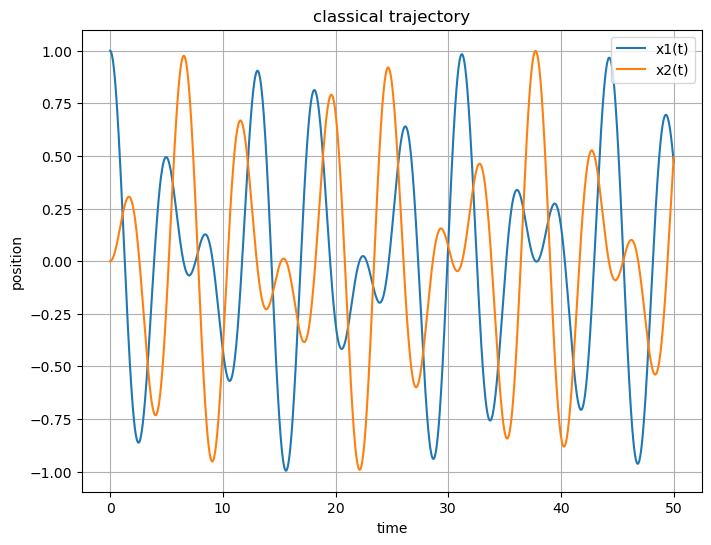

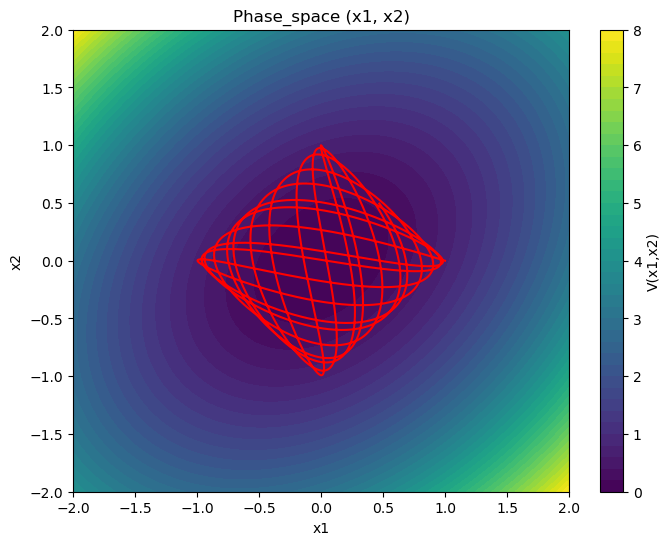

In [6]:
m = 1
k = 1
lam = 0.5
x10 = 1
x20 = 0
v10 = 0
v20 = 0

# Frequencies
omega_cm = np.sqrt(k/m)
omega_rel = np.sqrt(1 + 2*lam/k)

#time
t = np.linspace(0, 50, 4000)

# Transform to CM and relative coordinates
x_cm0 = (x10 + x20) / 2
x_rel0 = x10 - x20
v_cm0 = (v10 + v20) / 2
v_rel0 = v10 - v20

# Solve CM motion
# x_cm(t) = A cos(wt) + B sin(wt)
A_cm = x_cm0
B_cm = v_cm0 / omega_cm
x_cm = A_cm * np.cos(omega_cm * t) + B_cm * np.sin(omega_cm * t)

# Solve relative motion
A_rel = x_rel0
B_rel = v_rel0 / omega_rel
x_rel = A_rel * np.cos(omega_rel * t) + B_rel * np.sin(omega_rel * t)

# Back transformation
x1 = x_cm + x_rel / 2
x2 = x_cm - x_rel / 2

# Plot trajectories
plt.figure(figsize=(8, 6))
plt.plot(t, x1, label="x1(t)")
plt.plot(t, x2, label="x2(t)")
plt.xlabel("time")
plt.ylabel("position")
plt.title("classical trajectory")
plt.legend()
plt.grid()
plt.show()

#potential and trajectory
x = np.linspace(-2, 2, 300)
X1, X2 = np.meshgrid(x, x)
V = 0.5 * k * (X1**2 + X2**2) + 0.5 * lam * (X1 - X2)**2

#plot
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, V, levels=50)
plt.colorbar(label="V(x1,x2)")
plt.plot(x1, x2, color='red')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Phase_space (x1, x2)")
plt.show()

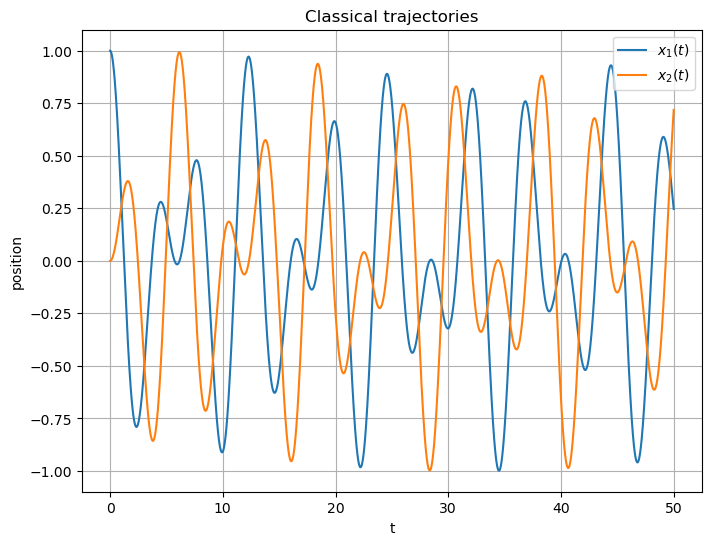

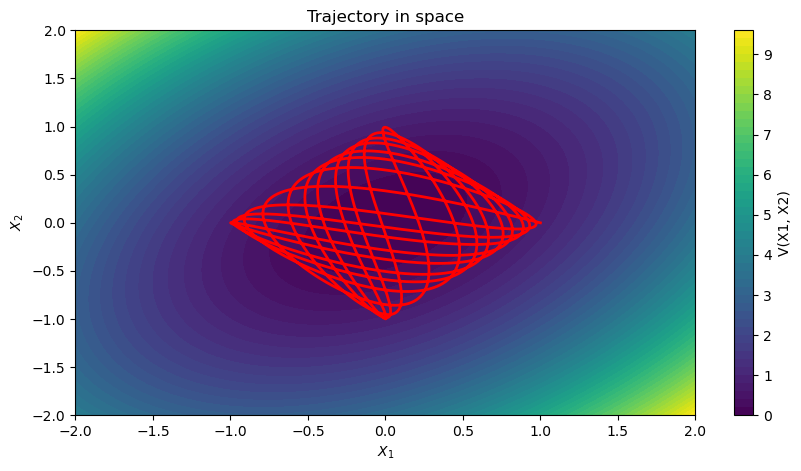

In [7]:
# Parameters
m = 1
k = 1
lam = 0.7
omega_cm = np.sqrt(k/m)
omega_rel = np.sqrt(1 + 2*lam/k)

# Time and Solutions x1 and x2 
t = np.linspace(0, 50, 4000)
x1 = 0.5*np.cos(omega_cm*t) + 0.5*np.cos(omega_rel*t)
x2 = 0.5*np.cos(omega_cm*t) - 0.5*np.cos(omega_rel*t)

# Plot trajectories
plt.figure(figsize=(8,6))
plt.plot(t, x1, label=r"$x_1(t)$")
plt.plot(t, x2, label=r"$x_2(t)$")
plt.xlabel("t")
plt.ylabel("position")
plt.title("Classical trajectories")
plt.legend()
plt.grid(True)
plt.show()

#density plot of the potential and Grid in configuration space
x = np.linspace(-2, 2, 300)
X1, X2 = np.meshgrid(x, x)
V = 0.5*k*(X1**2 + X2**2) + 0.5*lam*(X1 - X2)**2
traj_X1 = x1
traj_X2 = x2

# Density plot and Trajectory
plt.figure(figsize=(10,5))
plt.contourf(X1, X2, V, levels=50)
plt.colorbar(label="V(X1, X2)")
plt.plot(traj_X1, traj_X2, color='red', lw=2) 
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.title("Trajectory in space")
plt.show()

### Exercise 2

The exact eigenenergies can be read off from the Hamiltonian in CM and rel coordinates as the problem separates.
$$
E(n_{CM},n_{rel}) = (n_{CM}+1/2) \hbar \omega_{CM}+ (n_{rel}+1/2)\hbar \omega_{rel}
$$
The ground state energy is just $E_0 = E(0,0) = \frac{1}{2} \hbar (\omega_{CM}+\omega_{rel})=\frac{\hbar\omega}{2}(1+\sqrt{1+2\lambda/k})$.
We will use this analytical result to test the correctness and convergence of the basis set expansion approach we are going to employ now.

We want to expand the Hamiltonian in the eigenbasis of the 2D harmonic oscillator (use the same basis size $N_1=N_2=N_{max}$ for both oscillator modes 1 and 2. What is the resulting size of the basis set?). 
For this, one can expand the perturbation term $\frac{1}{2}\lambda(x_1 - x_2)^2$ into ladder operators and then apply it to the unperturbed basis states. Recall $x/x_{HO} = (a^\dagger + a)/\sqrt{2}$ and work in dimensionless units where $x_{HO}=1$.
How many off-diagonal elements will there be in each line? 

There are many ways of building the Hamiltonian matrix in the chosen basis. First, make sure you understand what the basis states are and how one would order them in a reasonable way.  
A fail-safe way to build up the Hamiltonian matrix is to iterate over all states of the chosen basis and determine the matrix-elments it couples to. We have provided the function `cqd.hamiltonians.build_H_coupled_HO_man(N1, N2, lam)` as a reference for you. Another, arguably more elegant, way which you are supposed to do is to build the matrix representing the annihilation operator on the Hilbert space of one of the oscillators. The creation operator is then simply the transpose of that and the position operator can be built by adding the two. We have a 2D problem so we work in a Hilbert space that is a tensor product of the two Hilbert spaces of the oscillators. Thus, to represent the position operator $\hat{x}_1$ acting on oscillator 1 in the full Hilbert space we have to use $\hat{x}_1 \otimes \mathbf{1}$, where $\mathbf{1}$ is the identity acting on the second oscillator. This can be achieved by using a Kronecker product. For multiplying or squaring operators you can use the numpy dot product function. Alternatively you can make use of the matrix multiplication operator `@`.

</div>
The second method has the advantage that it requires only to build one operator explicitly and the rest is matrix algebra (or two if you use different basis sizes for the two oscillators). Using sparse matrices this process can be very efficient.
Technical note of caution: The two described methods for building the Hamiltonian matrix might lead to slightly different results due to effects of the finite basis size. This will not affect the convergence of low lying eigenstates.

Diagonalize the Hamiltonian (built in both ways) and check your result by comparing the ground state energy to the exact result. How small can you make the basis such that the ground state energy is still converged? (You should find that $N_1=N_2=5$, i.e. 25 basis states, is sufficient to get the ground state with good precision up to $\lambda=2$.) Also look at some excited states, at least the lowest 6, make sure that your diagonalization results agree with the exact one, and understand the structure of the spectrum. Plot the eigenenergies for a grid of $\lambda$ values from 0 to 2.

Optional: As this problem can be solved analytically, we are complicating it by doing the basis set expansion. However, one could now use this method to apply it to non-integrable cases like a quartic (non-linear) coupling or even the quantum version of the Henon-Heiles problem, which does not separate and is classically chaotic!
If you want to go beyond, try other potentials!


In [8]:
lam_values = np.linspace(0, 2, 50)  # grid of lambda values from 0 to 2

E_num = []   # numerical ground state energies
E_exact = [] # analytical ground state energies
# loop over coupling strengths
for lam in lam_values: 
    # build Hamiltonian matrix for given lambda (5x5 basis)
    H = cqd.hamiltonians.build_H_coupled_HO_man(5, 5, lam)
    # compute lowest eigenvalue (ground state)
    eigvals, _ = eigsh(H, k=1, which='SA')
    # store numerical ground state energy
    E_num.append(eigvals[0])
    # store exact ground state energy at  (n_CM = n_rel = 0, k = m = 1)
    E_exact.append(cqd.hamiltonians.exact_energy_2D(0, 0, lam, 1, 1))
# convert lists to arrays for plotting
E_num = np.array(E_num)
E_exact = np.array(E_exact)

# plot results
plt.figure(figsize=(8,6))
plt.plot(lam_values, E_num, 'o', label="Numerical (N=5)")
plt.plot(lam_values, E_exact, '-', label="Exact")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$E_0$")
plt.title("Ground state energy: numerical vs exact")
plt.legend()
plt.grid()
plt.show()

AttributeError: module 'Comp_Quant_Dynam.hamiltonians' has no attribute 'exact_energy_2D'

In [ ]:
#Basis size:
N1 = 5
N2 = 5
Nbasis = N1 *  N2
print("Nbasis=", Nbasis)

In [ ]:
# build Hamiltonian
H = cqd.hamiltonians.build_H_coupled_HO_man(5, 5, lam = 1)

# convert to CSR format for efficient row access
H_csr = H.tocsr()
# count off-diagonal elements per row
off_diag_counts = []
#loop 
for i in range(H_csr.shape[0]):
    row = H_csr.getrow(i).toarray().flatten()
    # count all non-zero entries except diagonal
    off_diag = np.count_nonzero(row) - 1  # subtract diagonal element
    off_diag_counts.append(off_diag)
off_diag_counts = np.array(off_diag_counts)

#print result
print("Maximum off-diagonal elements per row=", off_diag_counts.max())
print("Minimum off-diagonal elements per row=", off_diag_counts.min())
print("Average off-diagonal elements per row=", off_diag_counts.mean())

8 off-diagonal elements per row (maximum in the bulk)

### Exercise 3 

Calculate the time evolution for different initial conditions (as on exercise sheet 2) using the eigenstates obtained in exercise 2. Try the following initial states: 1) oscillator 1 in the first excited state, oscillator two in its ground state $|0\rangle$; 2) oscillator 1 in $|\psi_0\rangle = (|0\rangle+|1\rangle)/\sqrt(2)$, oscillator two in state $|0\rangle$;  3) oscillator 1 in a coherent state (e.g. with $\langle n \rangle = |\alpha|^2 = 2$) and oscillator 2 in $|0\rangle$. Example parameters: $\lambda=0.2$, $N_1=N_2=10$, $t_f = 40$.

Monitor the dynamics by calculating $\langle x_1 \rangle$ and $\langle x_2 \rangle$. Compare your observations to the classical expectation: propagate a classical particle with $x_{i0}=\langle x_i(t=0) \rangle$ and $p_{i0}=\langle p_i(t=0) \rangle$. Describe and interpret your observations.

Calculate also the energy expectation value of each oscillator, as well as the probabilities for each oscillator to be in state $|n\rangle$. You should observe that the energy fluctuates between the oscillators.

Represent the wave function on a 2D spatial grid using the exact harmonic oscillator eigenfunctions (Hermite Polynomials...). Animate the time-dependence of the wave packet in a 2D density plot.